In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

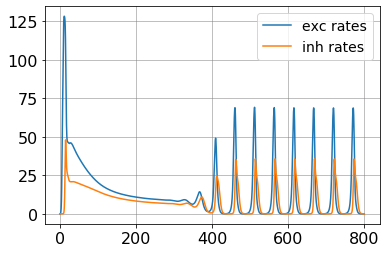

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

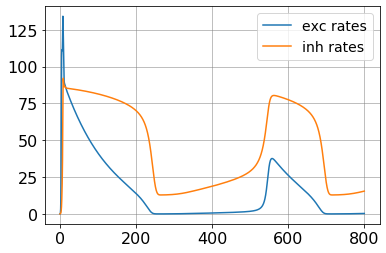

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

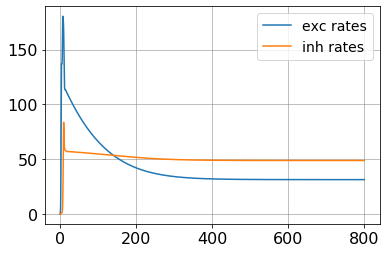

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

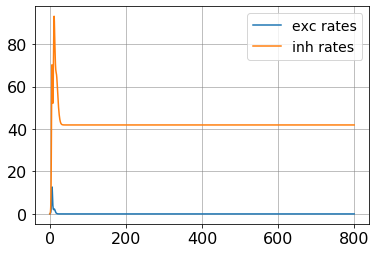

[4.4580e-10 4.1918e+01]


In [8]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [9]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

def gettranstimeatmax(target, init, n_dur, mintranstime, maxtranstime):
    max_ind = np.argmax(target[int(mintranstime*n_dur):int(maxtranstime*n_dur)])
    return ( max_ind + int(mintranstime*n_dur) ) / n_dur

In [10]:
dur = 1500
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

set_params_slow()
setinit(slow_osc_init)

aln.run(control = aln.getZeroControl())
slow_rates = np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] )

# set slow oscillation as target
target = aln.getZeroTarget()
target[0,0,:] = slow_rates[0,:]
target[0,1,:] = slow_rates[1,:]

In [11]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 500

set_params_fast()
initVars = fast_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = np.zeros((21))
trans_t = gettranstimeatmax(target[0,0,:], up_rates[0], n_dur, 0.05, 0.2)
trans_time_array[:] = trans_t

sheet = "G_a_"

## 14

In [ ]:
case_ind = 14
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  341773.32766868937
RUN  1 , total integrated cost =  327744.9968811213
RUN  2 , total integrated cost =  319848.10329829605
RUN  3 , total integrated cost =  319192.894372962
RUN  4 , total integrated cost =  318256.5068691872
RUN  5 , total integrated cost =  317055.34474062483
RUN  6 , total integrated cost =  315824.4814026192
RUN  7 , total integrated cost =  315359.6708539379
RUN  8 , total integrated cost =  314721.53608230676
RUN  9 , total integrated cost =  314382.10414763197
RUN  10 , total integrated cost =  313951.345568806
RUN  11 , total integrated cost =  313796.09948454803
RUN  12 , total integrated cost =  313266.17373061995
RUN  13 , total integrated cost =  312958.84622290044
RUN  14 , total integrated cost =  307977.35358932713
RUN  15 , total integrated cost =  305468.07508937543
RUN  16 , total integrated cost =  305397.5346731894
RUN  17 , total integrated cost =  305315.48530

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  178 , total integrated cost =  283868.0049562175
Improved over  178  iterations by  16.942610211117625  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -65.481077860303 -65.48326501616748


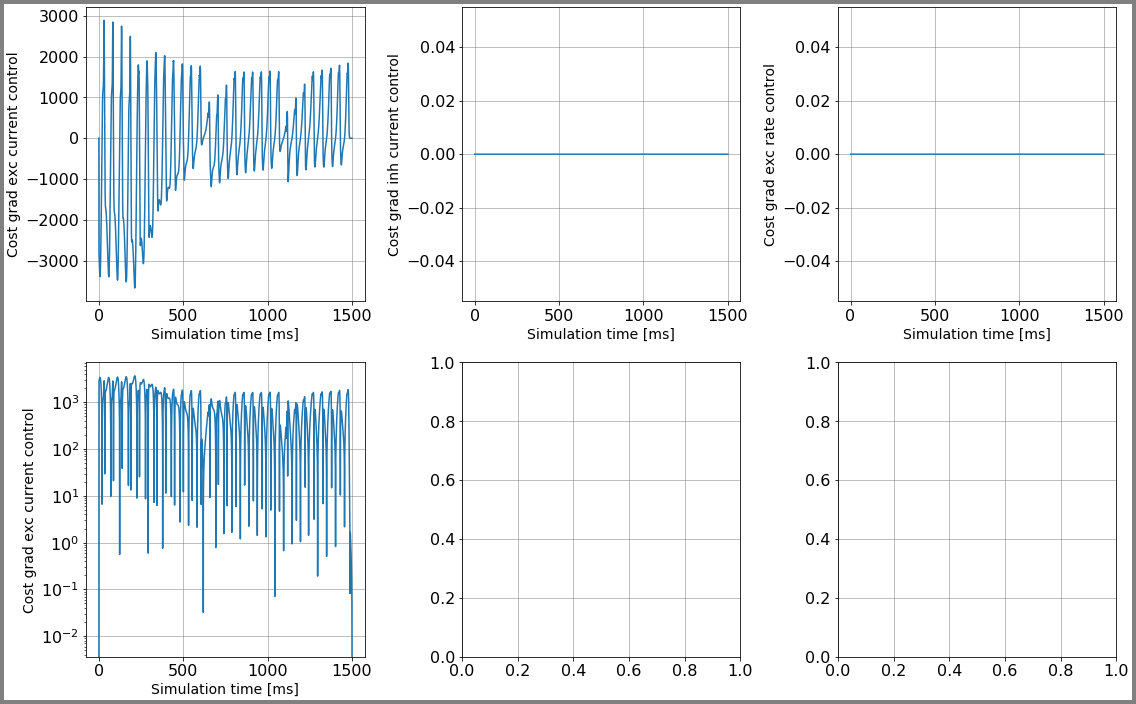

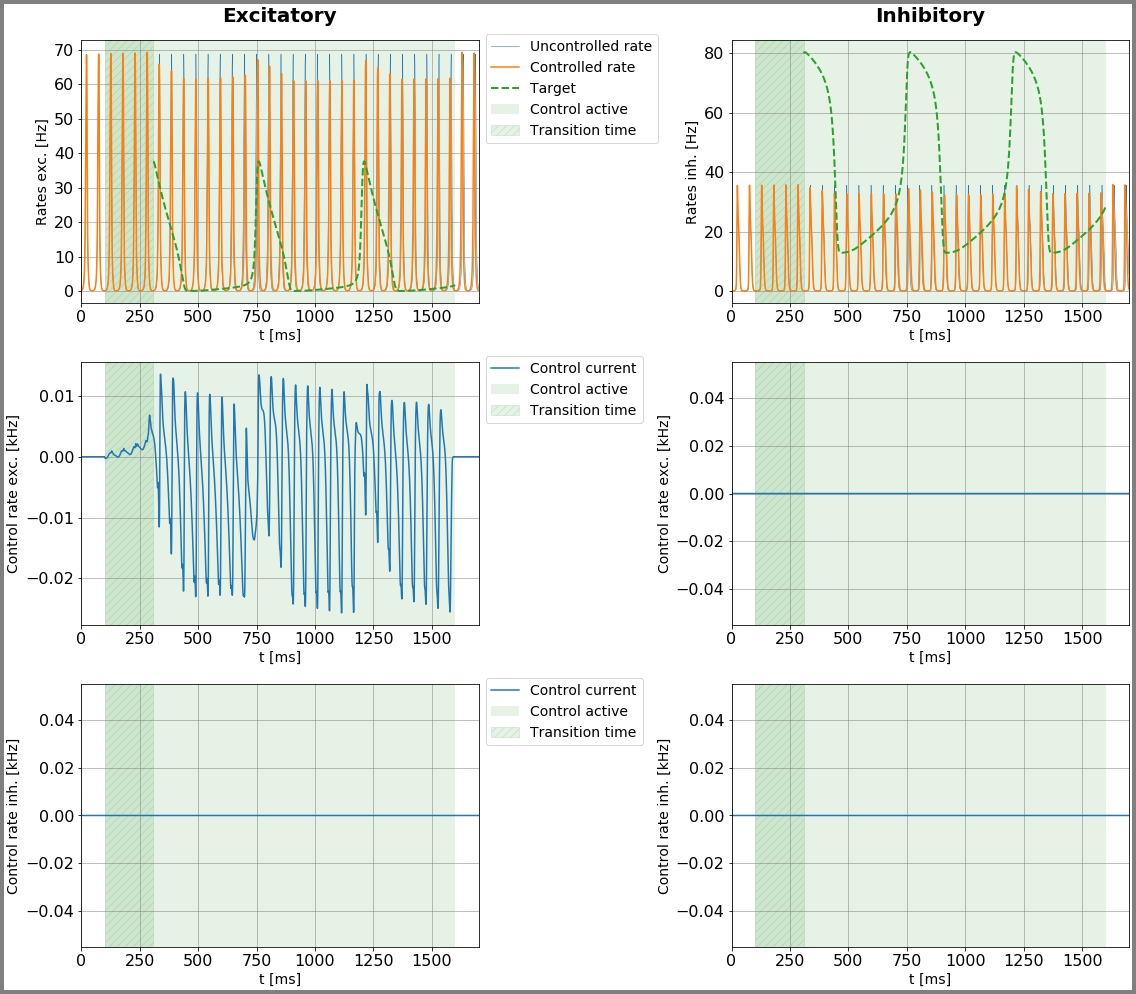

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 14
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 15

set cost params
control input:  [1] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  113752.42155690344
RUN  1 , total integrated cost =  113752.42051898771
RUN  2 , total integrated cost =  113752.41925987654
RUN  3 , total integrated cost =  113752.4180473247
RUN  4 , total integrated cost =  113752.41648250801
RUN  5 , total integrated cost =  113752.41497191148
RUN  6 , total integrated cost =  113752.41370061878
RUN  7 , total integrated cost =  113752.41250152992
RUN  8 , total integrated cost =  113752.41091597822
RUN  9 , total integrated cost =  113752.40942911369
RUN  10 , total integrated cost =  113752.40813976567
RUN  11 , total integrated cost =  113752.40681267994
RUN  12 , total integrated cost =  113752.40540829391
RUN  13 , total integrated cost =  113752.40404761521
RUN  14 , total integrated cost =  113752.40266429844
RUN  15 , total integrated cost =  113752.40128446813
RUN  16 , total integrated cost =  113752.39

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  500 , total integrated cost =  113751.46654113826
RUN  500 , total integrated cost =  113751.46654113826
Improved over  500  iterations in  207.19948680000016  seconds by  0.0008395564262286825  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -76.48423459191157 -76.48744990142168


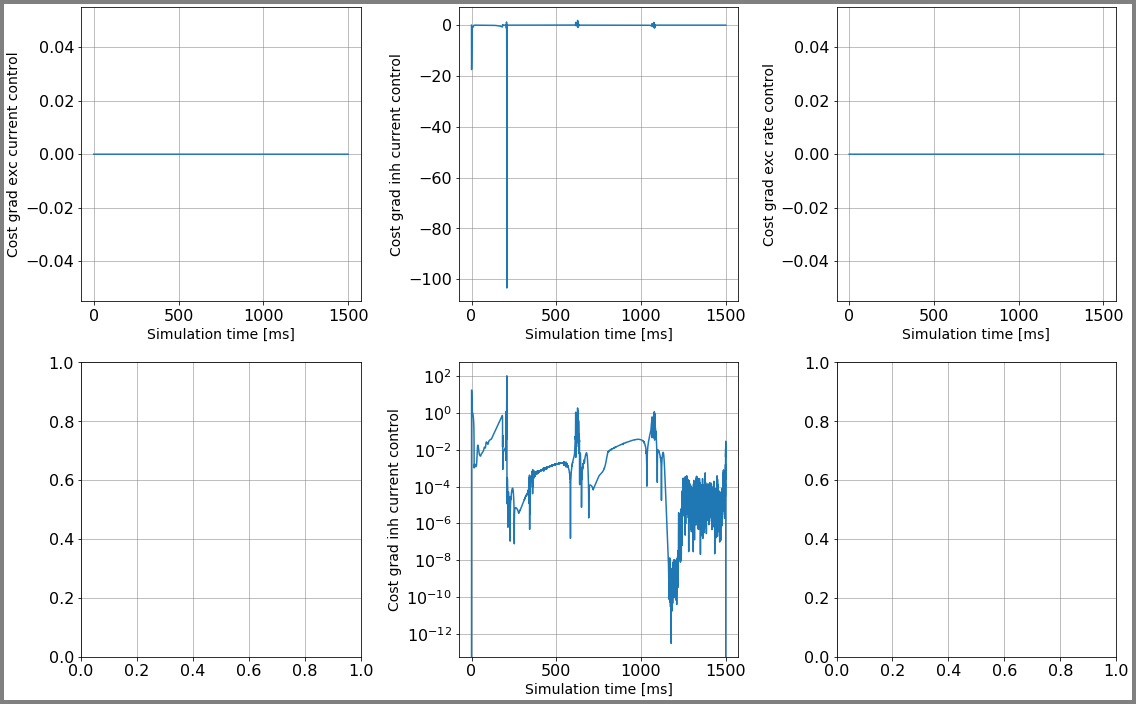

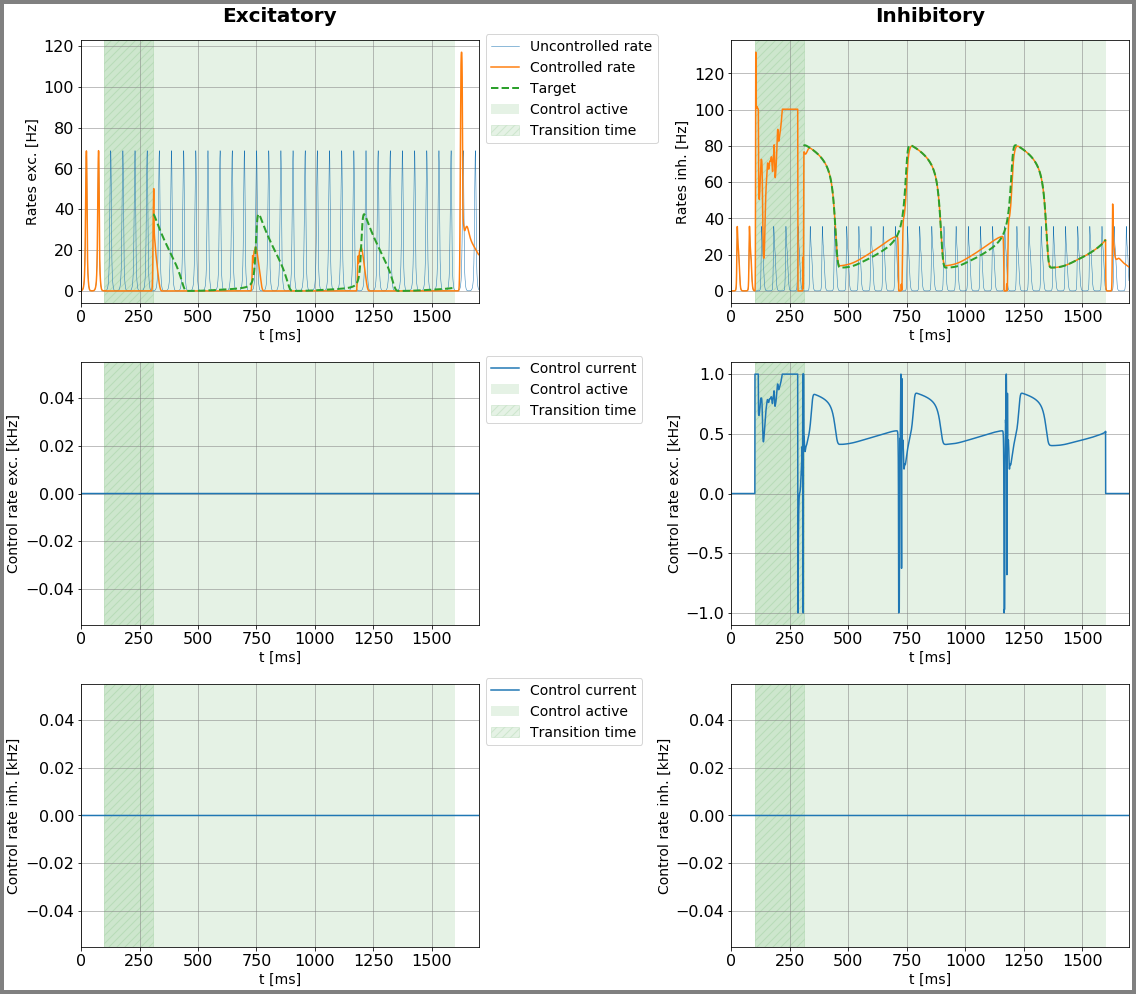

In [20]:
case_ind = 15
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  529210.6596644797
RUN  1 , total integrated cost =  529210.6334899091
RUN  2 , total integrated cost =  529210.6148802128
RUN  3 , total integrated cost =  529210.6093748914
RUN  4 , total integrated cost =  529210.5814375399
RUN  5 , total integrated cost =  529210.5259546353
RUN  6 , total integrated cost =  529210.5118488102
RUN  7 , total integrated cost =  529210.5103682858
RUN  8 , total integrated cost =  529210.5088461929
RUN  9 , total integrated cost =  529210.4935317392
RUN  10 , total integrated cost =  529210.480242993
RUN  11 , total integrated cost =  529210.4733029827
RUN  12 , total integrated cost =  529210.4725606003
RUN  13 , total integrated cost =  529210.4604939751
RUN  14 , total integrated cost =  529210.2015076298
RUN  15 , total integrated cost =  529210.1539730382
RUN  16 , total integrated cost =  529210.1223584118
RUN  17 , total integrated cost =  529210.0908206078
RUN

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  529131.4907578579
RUN  200 , total integrated cost =  529131.4907578579
Improved over  200  iterations in  163.99363710000034  seconds by  0.01495980951554543  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -64.7466700262257 -64.86151451802593


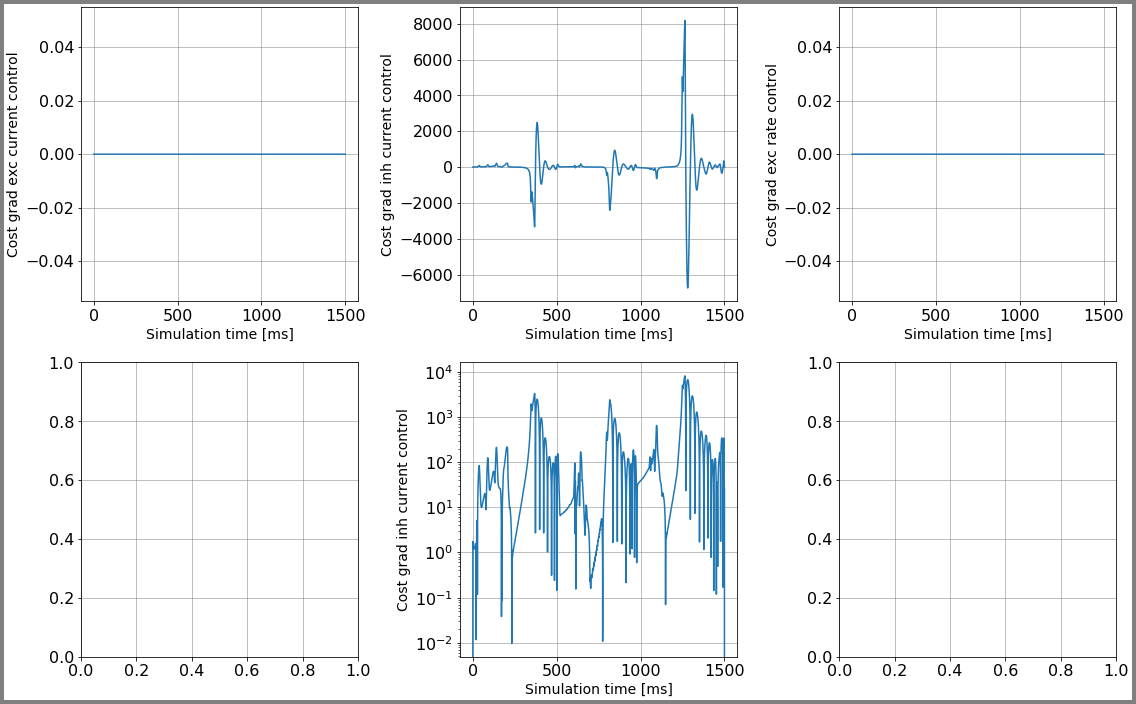

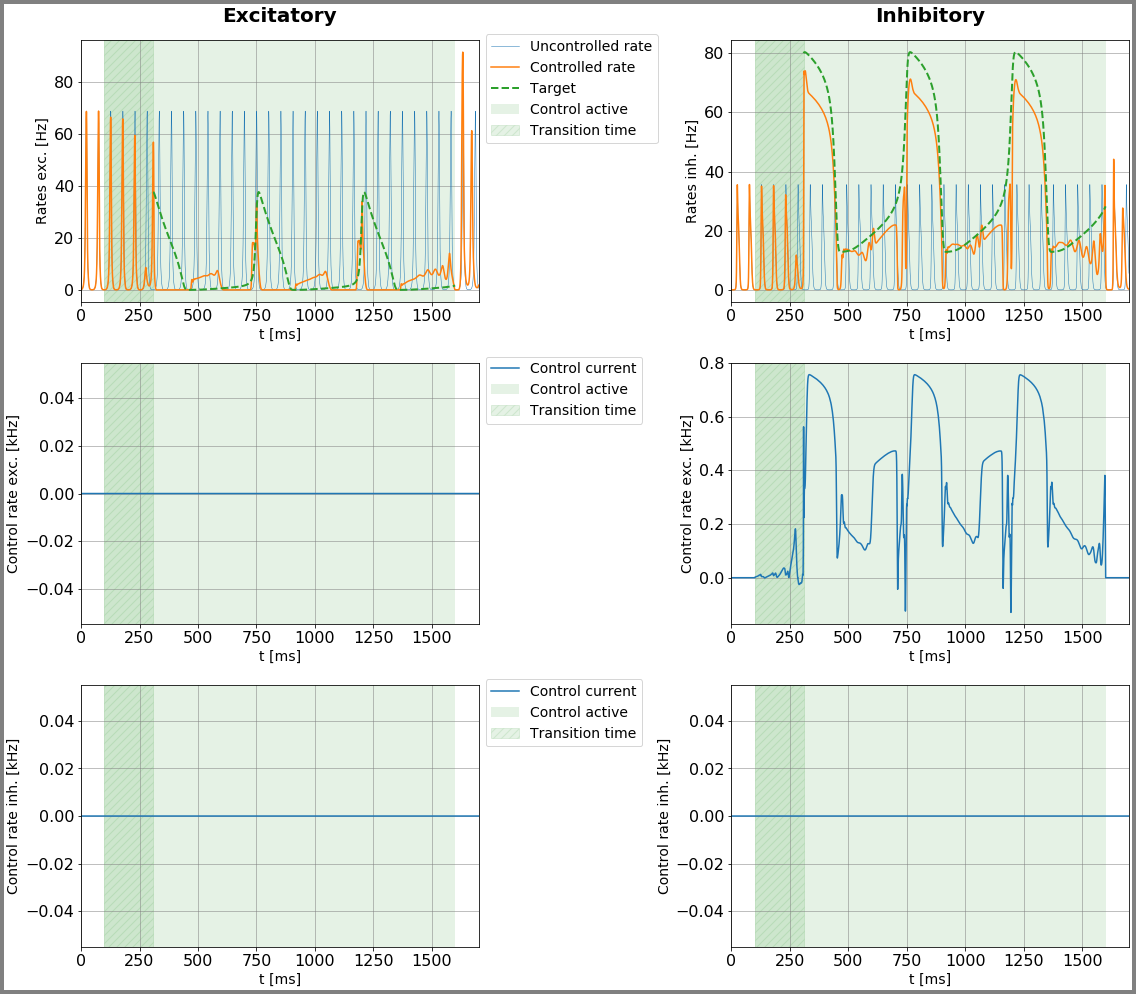

In [33]:
case_ind = 15
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = "HZ"
max_it = 200

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 16

In [ ]:
# A.4.a)

case_ind = 16
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  341773.32766868937
RUN  1 , total integrated cost =  181124.94831202846
RUN  2 , total integrated cost =  163361.81794258894
RUN  3 , total integrated cost =  153845.17037093788
RUN  4 , total integrated cost =  146034.22852136727
RUN  5 , total integrated cost =  141193.39531527043
RUN  6 , total integrated cost =  135286.42515547213
RUN  7 , total integrated cost =  130479.58347982385
RUN  8 , total integrated cost =  120801.08334162942
RUN  9 , total integrated cost =  119099.92213131668
RUN  10 , total integrated cost =  117521.17752469197
RUN  11 , total integrated cost =  116249.64235492951
RUN  12 , total integrated cost =  115012.76510466386
RUN  13 , total integrated cost =  114027.21312840321
RUN  14 , total integrated cost =  112985.18725968164
RUN  15 , total integrated cost =  112188.74896241227
RUN  16 , total integrated cost =  111308.8642

In [ ]:
case_ind = 16
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-7, 1e-7)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 17

In [ ]:
# A.6.a)
case_ind = 17
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 17
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-6, 1e-6)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 18

In [ ]:
# A.8.a)
case_ind = 18
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 18
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-3, 1e-3)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 19

set cost params
control input:  [1, 2] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19734.789145614977
RUN  1 , total integrated cost =  19734.782716609818
RUN  2 , total integrated cost =  19734.773219748513
RUN  3 , total integrated cost =  19734.766510319852
RUN  4 , total integrated cost =  19734.758808335762
RUN  5 , total integrated cost =  19734.749332018135
RUN  6 , total integrated cost =  19734.742908058062
RUN  7 , total integrated cost =  19734.732662041486
RUN  8 , total integrated cost =  19734.72758280613
RUN  9 , total integrated cost =  19734.720481458542
RUN  10 , total integrated cost =  19734.714099625235
RUN  11 , total integrated cost =  19734.709781387992
RUN  12 , total integrated cost =  19734.70605586151
RUN  13 , total integrated cost =  19734.701082387324
RUN  14 , total integrated cost =  19734.693032781917
RUN  15 , total integrated cost =  19734.687181769328
RUN  16 , total integrated cost =  19734.6

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  19734.146198693386
RUN  100 , total integrated cost =  19734.146198693386
Improved over  100  iterations in  118.59257670000079  seconds by  0.0032579366156255674  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -77.74691683197895 -77.74867577014385


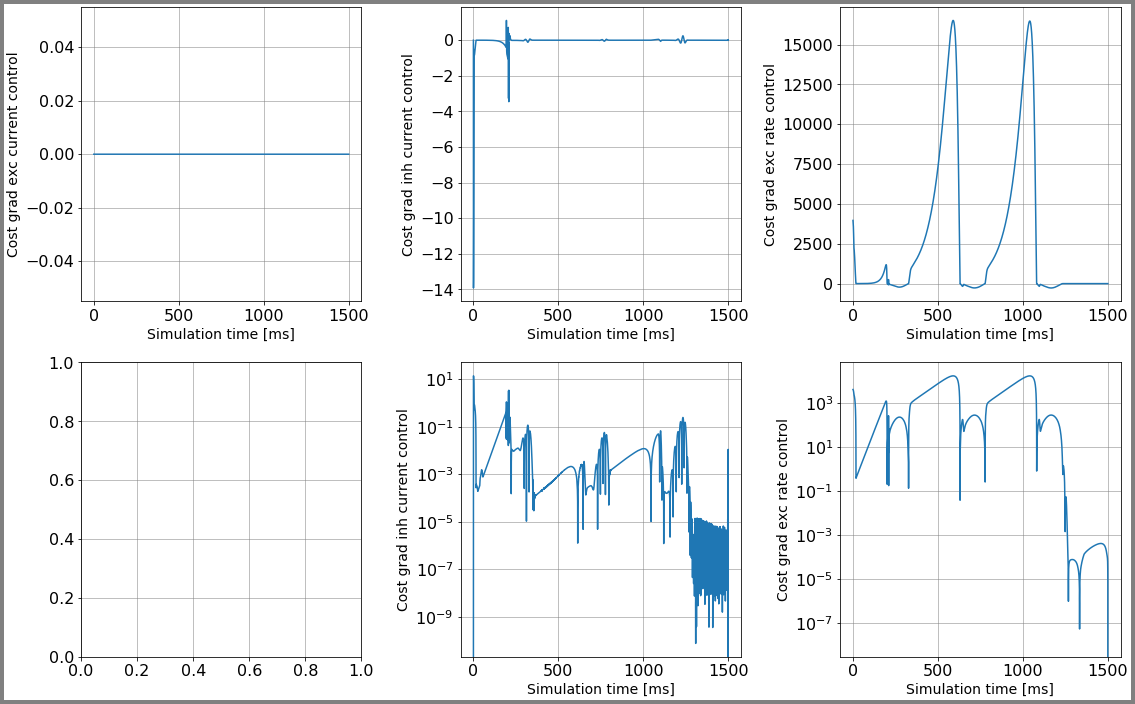

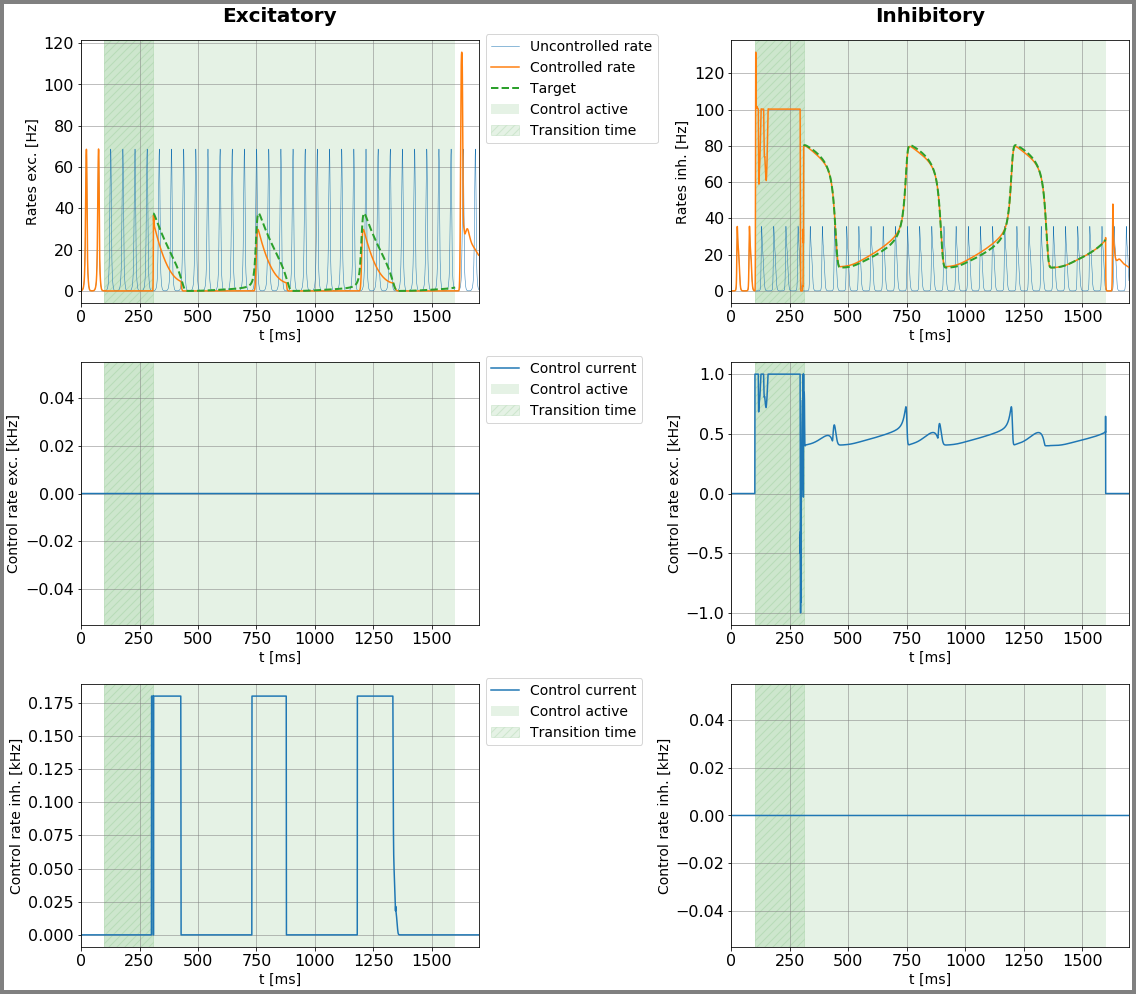

In [62]:
# A.10.a)
case_ind = 19
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5. - target[0,1,:]/16.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = "LS"
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 19
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]
cgv = "HS"
max_it = 200

for cgv in cgv_list:
    
    control2 = bestControlb[:,:,n_pre-1:-n_post+1]

    bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
        transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

    plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                          path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  355819.66397781466
RUN  1 , total integrated cost =  355819.25784447877
RUN  2 , total integrated cost =  355819.01997223
RUN  3 , total integrated cost =  355818.89676306205
RUN  4 , total integrated cost =  355818.82933130575
RUN  5 , total integrated cost =  355818.79280380084
RUN  6 , total integrated cost =  355818.7732973638
RUN  7 , total integrated cost =  355818.7592742305
RUN  8 , total integrated cost =  355818.74880219396
RUN  9 , total integrated cost =  355818.7367475947
RUN  10 , total integrated cost =  355818.7225000875
RUN  11 , total integrated cost =  355818.69620238204
RUN  12 , total integrated cost =  355818.67751930316
RUN  13 , total integrated cost =  355818.5282192036
RUN  14 , total integrated cost =  355818.41396414896
RUN  15 , total integrated cost =  355818.30666115583
RUN  16 , total integrated cost =  355818.23652964755
RUN  17 , total integrated cost =  355818.2306

## 20

In [ ]:
# A.12.a)
case_ind = 20
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 20
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-3, 1e-3)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )